In [24]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from sklearn.model_selection import train_test_split

from config import SEED


## Carga de datos

In [3]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

In [4]:
dataset = 'aug_sin_proc'

## Imagenes

In [5]:
train_dir = f'./dataset/ciclos_procesados/{dataset}/imgs/train'
val_dir = f'./dataset/ciclos_procesados/{dataset}/imgs/val'
test_dir = f'./dataset/ciclos_procesados/{dataset}/imgs/test'

In [6]:
X_train, y_train = load_image_dataset(train_dir, target_size=(372, 128))
X_val, y_val = load_image_dataset(val_dir, target_size=(372, 128))
X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128))

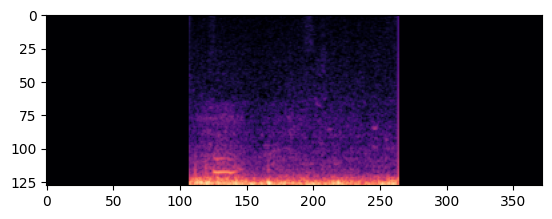

In [13]:
plt.imshow(X_train[4]);

In [14]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(128, 372, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_11564\184640210.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [15]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# lr_schedule = keras.optimizers.schedules.PolynomialDecay(
#     initial_learning_rate=1e-3,
#     decay_steps=5000,
#     end_learning_rate=1e-7,
#     power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(),#learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [17]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 346s 656ms/step - auc: 0.5720 - loss: 0.6896 - recall: 0.5722 - val_auc: 0.6180 - val_loss: 0.6783 - val_recall: 0.8161
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 346s 667ms/step - auc: 0.6062 - loss: 0.6746 - recall: 0.5967 - val_auc: 0.6295 - val_loss: 0.6733 - val_recall: 0.8166
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 354s 682ms/step - auc: 0.6211 - loss: 0.6701 - recall: 0.6234 - val_auc: 0.6345 - val_loss: 0.6646 - val_recall: 0.6604
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 357s 688ms/step - auc: 0.6343 - loss: 0.6632 - recall: 0.6280 - val_auc: 0.6466 - val_loss: 0.6588 - val_recall: 0.7088
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 355s 684ms/step - auc: 0.6367 - loss: 0.6627 - recall: 0.6297 - val_auc: 0.6497 - val_loss: 0.6617 - val_recall: 0.6614
Epoch 6/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 364s 701ms/step - auc: 0.6463 - loss: 0.6577 - recall: 0.6535 - val_auc: 0.6556 - val_loss: 0.6572 - val_recall: 0.7385
Epoch 7/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 

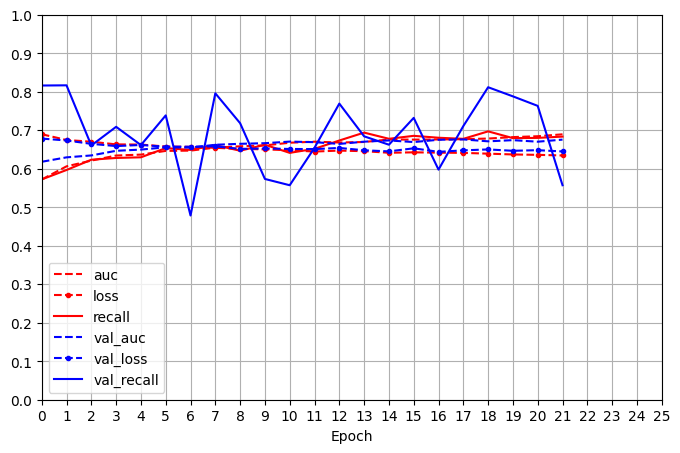

In [19]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 25], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 26), yticks=np.arange(0, 1.1, 0.1))
plt.show()

In [20]:
model.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 77s 477ms/step - auc: 0.6655 - loss: 0.6510 - recall: 0.6133


[0.6509820818901062, 0.6654943227767944, 0.6133491396903992]

In [21]:
model.save(f'./neural_network/modelos/{dataset}.keras')

## Arrays

In [22]:
train_data = np.load(f'./dataset/ciclos_procesados/{dataset}/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load(f'./dataset/ciclos_procesados/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)

In [26]:
X_train = X_train.reshape(-1, 128, 372, 1)
X_val = X_val.reshape(-1, 128, 372, 1)
X_test = X_test.reshape(-1, 128, 372, 1)

In [27]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

In [28]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(128, 372, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_11564\182398130.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [29]:
model_melspec.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [31]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [32]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 520s 967ms/step - auc_1: 0.5438 - loss: 0.6978 - recall_1: 0.4963 - val_auc_1: 0.5932 - val_loss: 0.6790 - val_recall_1: 0.7448
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 512s 986ms/step - auc_1: 0.5691 - loss: 0.6846 - recall_1: 0.5574 - val_auc_1: 0.6040 - val_loss: 0.6774 - val_recall_1: 0.6963
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 459s 884ms/step - auc_1: 0.5856 - loss: 0.6813 - recall_1: 0.5618 - val_auc_1: 0.6058 - val_loss: 0.6870 - val_recall_1: 0.9006
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 556s 988ms/step - auc_1: 0.5994 - loss: 0.6780 - recall_1: 0.5657 - val_auc_1: 0.6140 - val_loss: 0.6812 - val_recall_1: 0.8155
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 534s 1s/step - auc_1: 0.6008 - loss: 0.6763 - recall_1: 0.5624 - val_auc_1: 0.5997 - val_loss: 0.6785 - val_recall_1: 0.2854
Epoch 6/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 645s 1s/step - auc_1: 0.6089 - loss: 0.6734 - recall_1: 0.5546 - val_auc_1: 0.6276 - val_loss: 0.6676 - val_recall_1: 0.559

In [33]:
model_melspec.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 104s 643ms/step - auc_1: 0.6257 - loss: 0.6681 - recall_1: 0.7227


[0.6681255102157593, 0.6256831884384155, 0.7227488160133362]

In [34]:
model_melspec.save(f'./neural_network/modelos/{dataset}_melspec.keras')